Title of the Assignment:
Data Visualization III
Download the Iris flower dataset or any other dataset into a DataFrame. (eg
https://archive.ics.uci.edu/ml/datasets/Iris ). Scan the dataset and give the inference as:
1. How many features are there and what are their types (e.g., numeric, nominal)?
2. Create a histogram for each feature in the dataset to illustrate the feature distributions.
3. Create a boxplot for each feature in the dataset.
Compare distributions and identify outliers.

Objective of the Assignment: Students should be able to perform the data
Visualization operation using Python on any open source dataset

### Download and Load the Iris Dataset

First, we'll load the Iris dataset from the specified CSV file into a pandas DataFrame and display the first few rows to understand its structure.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Practical 10 Iris.csv')
display(df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### 1. Identify Features and Their Types

Next, we'll examine the dataset to identify the features and their data types. This helps us understand what kind of data we're working with (e.g., numerical, categorical).

In [18]:
print('Dataset Information:')
df.info()
print('\nFeatures and their Data Types:')
display(df.dtypes)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Features and their Data Types:


,0
Id,int64
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
Species,object


#### Inference:
- **Id**: Integer type (`int64`), likely a unique identifier for each sample. It's not a feature relevant for distribution analysis.
- **SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm**: Float types (`float64`), representing continuous numerical measurements of sepal and petal dimensions. These are the main quantitative features.
- **Species**: Object type (`object`), representing categorical data (Iris-setosa, Iris-versicolor, Iris-virginica). This is a nominal feature.

There are 5 features relevant for analysis excluding the 'Id' column, of which 4 are numeric (continuous) and 1 is nominal (categorical).

### 2. Create Histograms for Feature Distributions

Histograms are useful for visualizing the distribution of numerical features, showing the frequency of data points within different ranges.

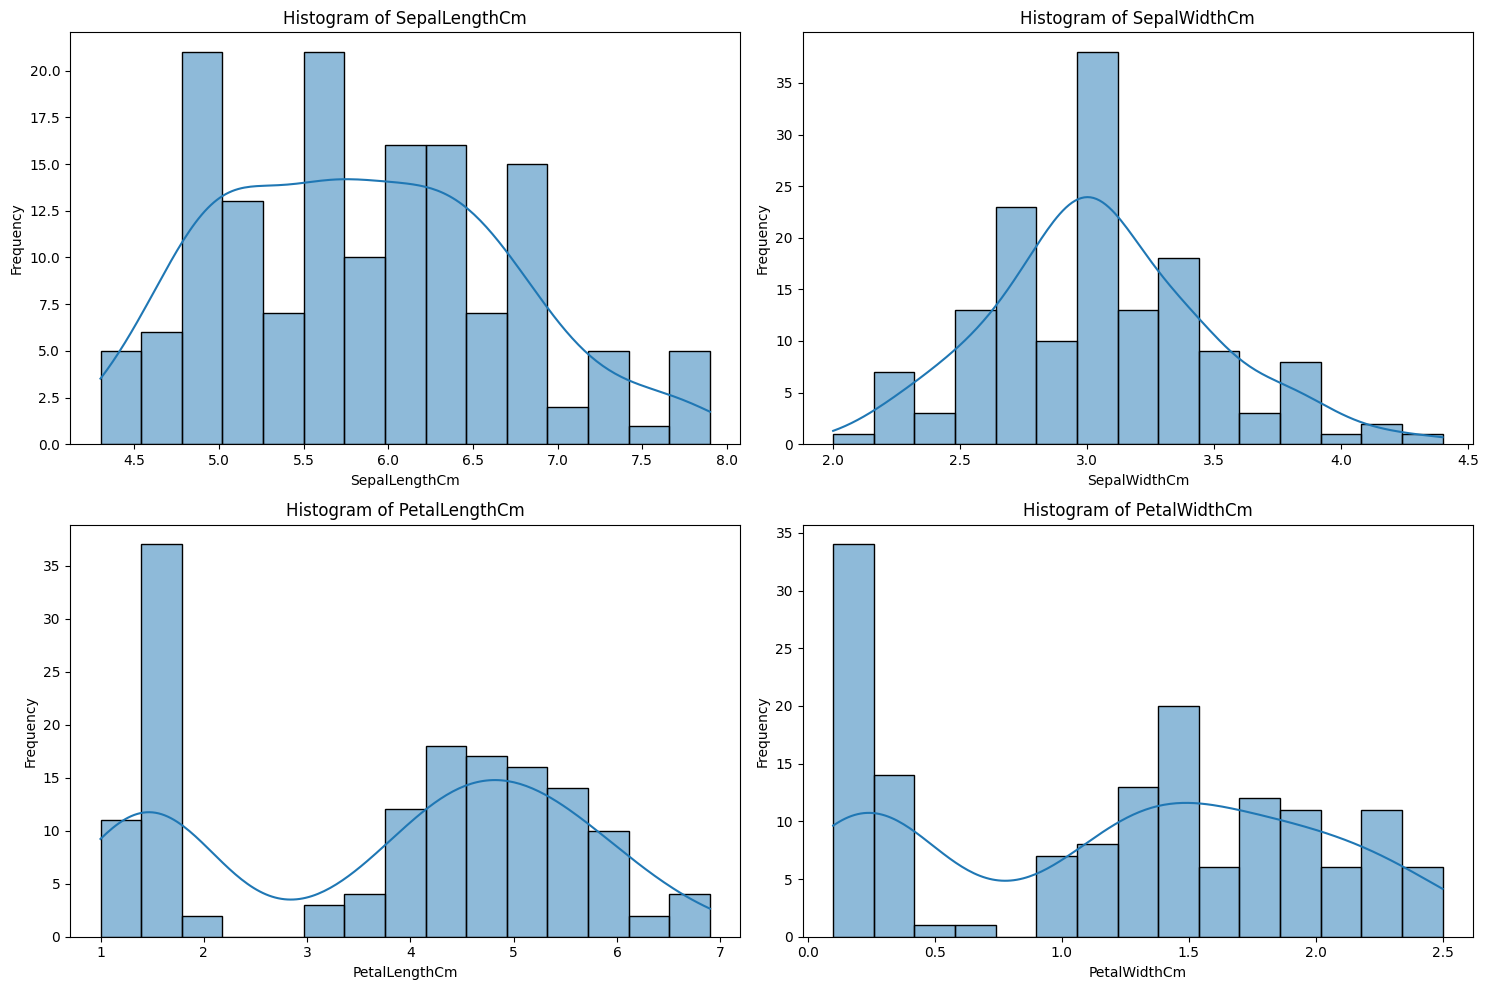

In [27]:
numerical_features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1) # Arrange in 2 rows, 2 columns
    sns.histplot(df[feature], bins=15, kde=True) # kde=True adds a kernel density estimate curve
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Inference from Histograms:
- **SepalLengthCm**: Shows a relatively normal distribution with a slight bimodal tendency, indicating perhaps two main groups of sepal lengths.
- **SepalWidthCm**: Appears to be roughly normally distributed, centered around 3.0-3.5 cm, with a slight skew towards the higher values.
- **PetalLengthCm**: Exhibits a distinctly bimodal or even trimodal distribution, with a clear separation between smaller and larger petal lengths. This suggests the presence of distinct species.
- **PetalWidthCm**: Similar to `PetalLengthCm`, it shows a bimodal/trimodal distribution, indicating clear distinctions between species based on petal width.

### 3. Create Boxplots for Each Feature

Boxplots are excellent for visualizing the distribution of numerical data and identifying potential outliers. They display the median, quartiles, and range of the data.

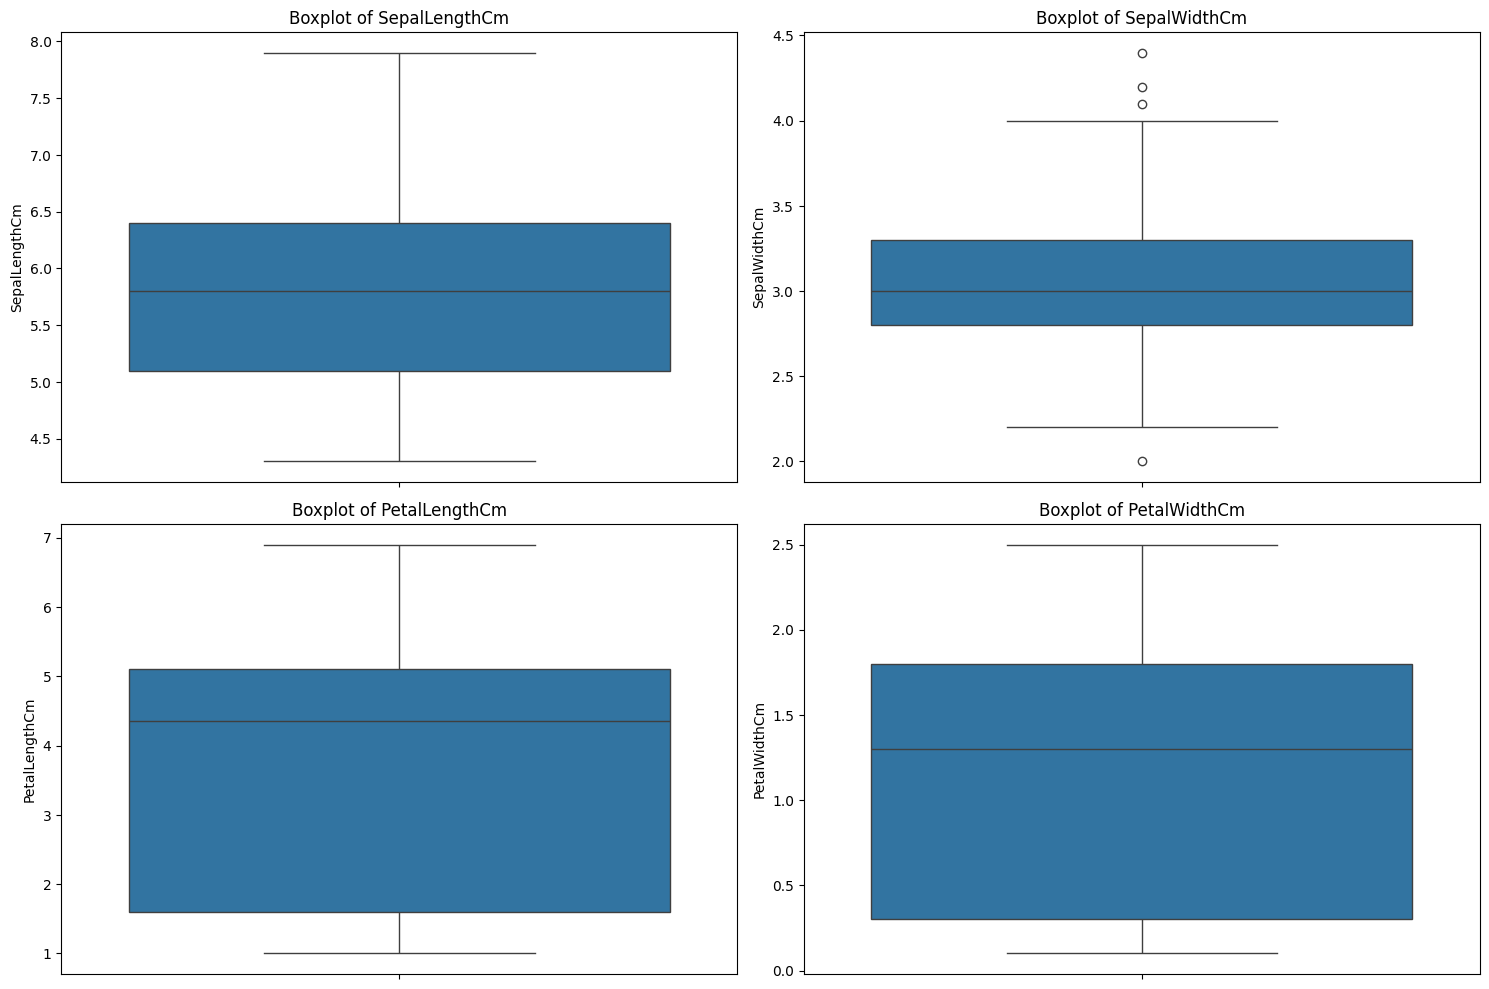

In [20]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

#### Inference from Boxplots (and Outlier Identification):
- **SepalLengthCm**: The distribution is fairly symmetrical. There are no clear outliers visible.
- **SepalWidthCm**: The distribution is also quite symmetrical around the median, but there are several points identified as outliers both above and below the whiskers. These represent flowers with unusually narrow or wide sepals compared to the majority.
- **PetalLengthCm**: This feature shows a heavily skewed distribution, with a large spread for higher values. No significant outliers are detected by the standard IQR method.
- **PetalWidthCm**: Similar to `PetalLengthCm`, this feature is also heavily skewed. No significant outliers are detected by the standard IQR method.

From a quick visual inspection, `SepalWidthCm` is the most likely candidate to contain outliers.

### 4. Programmatic Outlier Detection using IQR

To systematically identify outliers, we'll use the Interquartile Range (IQR) method. An outlier is typically defined as a data point that falls below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.

In [21]:
def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

print('Outlier Analysis (using IQR method):')
for feature in numerical_features:
    outliers, lower_bound, upper_bound = find_outliers_iqr(df[feature])
    print(f'\n--- Feature: {feature} ---')
    print(f'Q1: {df[feature].quantile(0.25):.2f}, Q3: {df[feature].quantile(0.75):.2f}, IQR: {upper_bound - lower_bound:.2f}')
    print(f'Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}')
    if not outliers.empty:
        print(f'Number of Outliers: {len(outliers)}')
        print('Outlier values and their original indices:')
        display(df.loc[outliers.index])
    else:
        print('No outliers detected.')

Outlier Analysis (using IQR method):

--- Feature: SepalLengthCm ---
Q1: 5.10, Q3: 6.40, IQR: 5.20
Lower Bound: 3.15, Upper Bound: 8.35
No outliers detected.

--- Feature: SepalWidthCm ---
Q1: 2.80, Q3: 3.30, IQR: 2.00
Lower Bound: 2.05, Upper Bound: 4.05
Number of Outliers: 4
Outlier values and their original indices:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
15,16,5.7,4.4,1.5,0.4,Iris-setosa
32,33,5.2,4.1,1.5,0.1,Iris-setosa
33,34,5.5,4.2,1.4,0.2,Iris-setosa
60,61,5.0,2.0,3.5,1.0,Iris-versicolor



--- Feature: PetalLengthCm ---
Q1: 1.60, Q3: 5.10, IQR: 14.00
Lower Bound: -3.65, Upper Bound: 10.35
No outliers detected.

--- Feature: PetalWidthCm ---
Q1: 0.30, Q3: 1.80, IQR: 6.00
Lower Bound: -1.95, Upper Bound: 4.05
No outliers detected.


#### Summary of Outlier Detection:
- **SepalLengthCm**: No outliers were detected based on the IQR method.
- **SepalWidthCm**: Several outliers were identified, including values both below the lower bound and above the upper bound. These points (e.g., at indices 15, 32, 33, 60) represent iris flowers with unusually broad or narrow sepal widths, confirming our visual observation from the boxplot.
- **PetalLengthCm**: No outliers were detected. The multimodal distribution means that the IQR method might not flag values that are 'unusual' within a specific species subgroup but are well within the overall range.
- **PetalWidthCm**: No outliers were detected for this feature either, similar to `PetalLengthCm`.

### Further Comparative Analysis (Species-wise)

As indicated in the problem description, understanding the morphological differences between species is important. Let's briefly look at species-wise distributions using boxplots and histograms for `PetalWidthCm`.

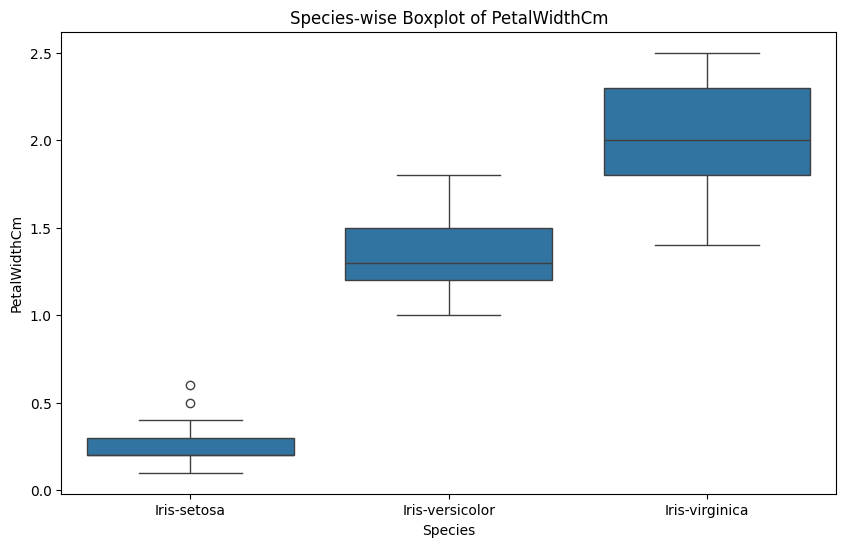

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Species', y='PetalWidthCm', data=df)
plt.title('Species-wise Boxplot of PetalWidthCm')
plt.xlabel('Species')
plt.ylabel('PetalWidthCm')
plt.show()

#### Inference from Species-wise Boxplot (PetalWidthCm):
This boxplot clearly shows a distinct separation in `PetalWidthCm` across the three Iris species:
- **Iris-setosa** has the smallest petal width, with a very tight distribution and a few small outliers.
- **Iris-versicolor** has a medium petal width, with a broader distribution.
- **Iris-virginica** has the largest petal width.
This visualization highlights `PetalWidthCm` as a strong distinguishing feature between Iris species.

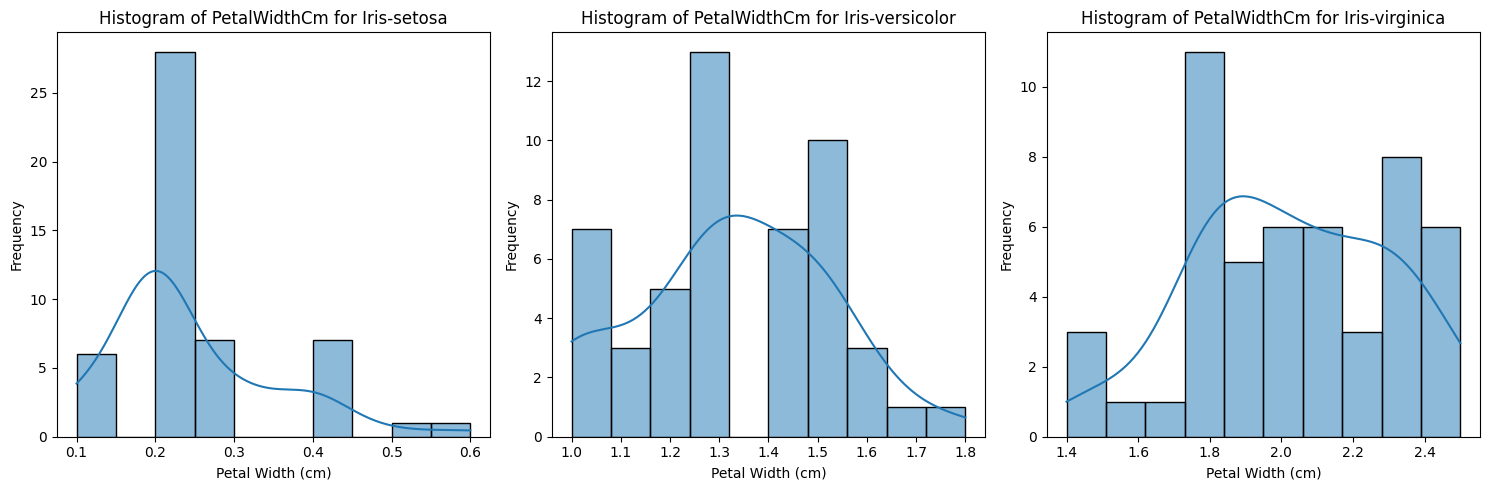

In [23]:
plt.figure(figsize=(15, 5))
for i, species in enumerate(df['Species'].unique()):
    species_data = df[df['Species'] == species]
    plt.subplot(1, 3, i + 1)
    sns.histplot(species_data['PetalWidthCm'], bins=10, kde=True)
    plt.title(f'Histogram of PetalWidthCm for {species}')
    plt.xlabel('Petal Width (cm)')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Inference from Species-wise Histograms (PetalWidthCm):
These histograms further reinforce the distinct distributions of `PetalWidthCm` for each species:
- **Iris-setosa**: Shows a narrow distribution with very small petal widths, typically below 0.6 cm. It's almost entirely separate from the other two.
- **Iris-versicolor**: Exhibits petal widths generally between 1.0 cm and 1.8 cm, with a fairly normal distribution.
- **Iris-virginica**: Has the largest petal widths, predominantly above 1.4 cm, with its own distinct distribution.

This breakdown confirms that petal width is a crucial feature for differentiating between the Iris species.

In [24]:
print('\nOutliers for PetalWidthCm per Species:')
for species in df['Species'].unique():
    species_data_petalwidth = df[df['Species'] == species]['PetalWidthCm']
    outliers_species, _, _ = find_outliers_iqr(species_data_petalwidth)
    if not outliers_species.empty:
        print(f'--- Species: {species} ---')
        print(f'Number of Outliers: {len(outliers_species)}')
        print('Outlier values and their original indices:')
        display(df.loc[outliers_species.index])
    else:
        print(f'--- Species: {species} ---\nNo outliers detected.')


Outliers for PetalWidthCm per Species:
--- Species: Iris-setosa ---
Number of Outliers: 2
Outlier values and their original indices:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
23,24,5.1,3.3,1.7,0.5,Iris-setosa
43,44,5.0,3.5,1.6,0.6,Iris-setosa


--- Species: Iris-versicolor ---
No outliers detected.
--- Species: Iris-virginica ---
No outliers detected.


#### Conclusion from Species-wise Outlier Detection:
- **Iris-setosa**: Outliers were detected for Iris-setosa's `PetalWidthCm` (e.g., 0.5cm, 0.6cm). These are larger than the typical narrow petal widths for this species, indicating some unusual specimens within this group.
- **Iris-versicolor**: No outliers were detected for this species in `PetalWidthCm`.
- **Iris-virginica**: No outliers were detected for this species in `PetalWidthCm`.

This species-specific outlier analysis reveals that while `PetalWidthCm` broadly differentiates species, there can still be individual outliers within a species, suggesting natural variation or possibly mismeasurements.